## Scatter Matrix (test group behavior)

We want to check relationships that might be **non-linear**, so correlation alone is not enough.
In this notebook, we build a dataframe for **test users** containing:
- avg_diff: average (first_commit - deadline) in hours, excluding project1
- pageviews: number of newsfeed visits from `pageviews`
- commits: number of commits from `checker`, excluding project1

Then we draw a scatter matrix with KDE on the diagonal.

In [1]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

# Connect to the database (we are inside src/ex06, so ../data is correct)
con = sqlite3.connect("../data/checking-logs.sqlite")

In [2]:
# 1) Average diff per user (test users only), exclude project1.
# We compute first commit per lab (MIN(timestamp)), join deadlines (unixepoch),
# then average the diff in hours per user.
q_avg = """
WITH test_users AS (
  SELECT DISTINCT uid
  FROM pageviews
  WHERE uid LIKE 'user_%'
),
first_commits AS (
  SELECT uid, labname, MIN(timestamp) AS first_commit_ts
  FROM checker
  WHERE uid IN (SELECT uid FROM test_users)
    AND uid LIKE 'user_%'
    AND labname <> 'project1'
  GROUP BY uid, labname
),
diffs AS (
  SELECT
    fc.uid AS uid,
    (julianday(fc.first_commit_ts) - julianday(d.deadlines, 'unixepoch')) * 24.0 AS diff_hours
  FROM first_commits fc
  JOIN deadlines d ON d.labs = fc.labname
)
SELECT uid, AVG(diff_hours) AS avg_diff
FROM diffs
GROUP BY uid;
"""
df_avg = pd.read_sql(q_avg, con)

# 2) Pageviews count per user (test users are exactly those who appear here)
q_views = """
SELECT uid, COUNT(*) AS pageviews
FROM pageviews
WHERE uid LIKE 'user_%'
GROUP BY uid;
"""
df_views = pd.read_sql(q_views, con)

# 3) Commits count per user from checker, exclude project1, and restrict to test users
q_commits = """
WITH test_users AS (
  SELECT DISTINCT uid
  FROM pageviews
  WHERE uid LIKE 'user_%'
)
SELECT uid, COUNT(*) AS commits
FROM checker
WHERE uid IN (SELECT uid FROM test_users)
  AND uid LIKE 'user_%'
  AND labname <> 'project1'
GROUP BY uid;
"""
df_commits = pd.read_sql(q_commits, con)

# Merge into one dataframe (only users that have all 3 values)
df = (
    df_avg.merge(df_views, on="uid", how="inner")
          .merge(df_commits, on="uid", how="inner")
)

df.head()

,uid,avg_diff,pageviews,commits
0,user_1,-65.119644,28,62
1,user_10,-75.242310,89,20
2,user_14,-159.568696,143,61
3,user_17,-62.207514,47,51
4,user_18,-6.367907,3,5


Text(0.5, 1.02, 'Scatter Matrix: avg_diff vs pageviews vs commits (test group)')

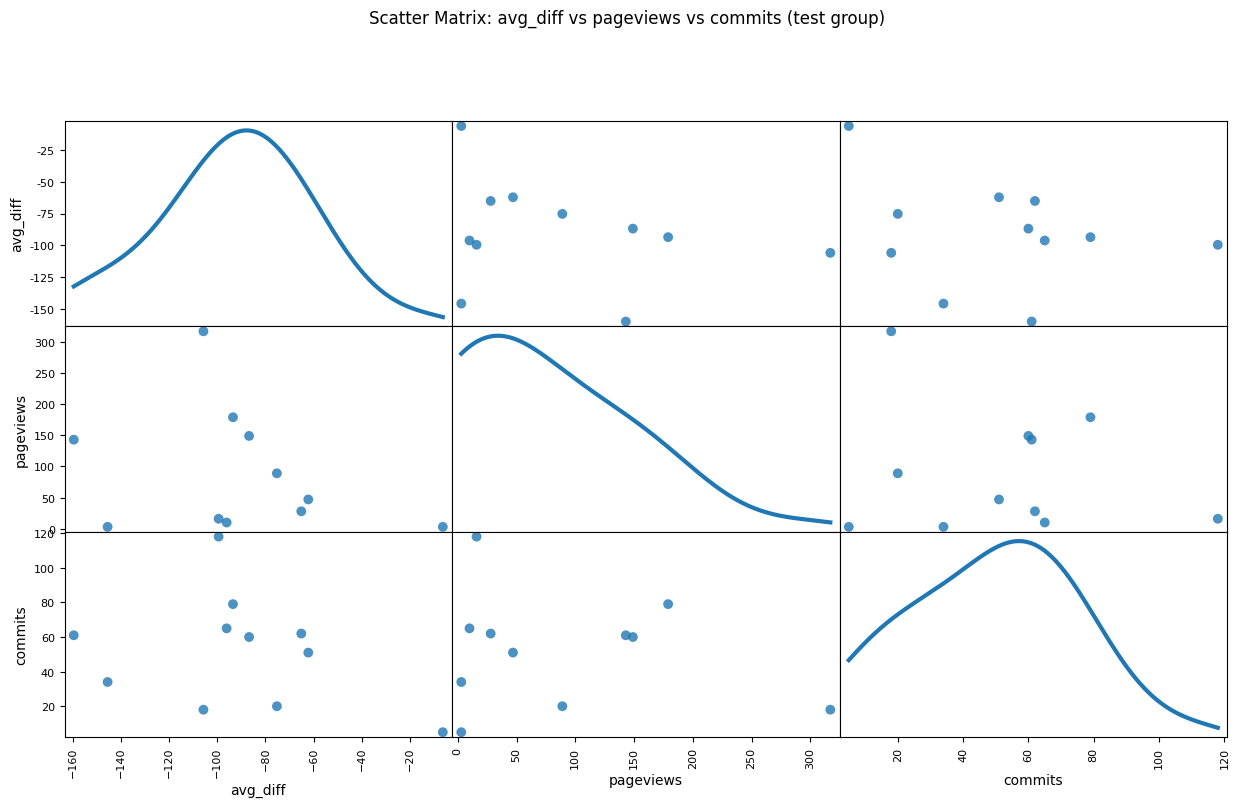

In [3]:
# Scatter matrix wants numeric columns only
features = df[["avg_diff", "pageviews", "commits"]]

axes = scatter_matrix(
    features,
    figsize=(15, 8),
    diagonal="kde",
    s=200,
    alpha=0.8,
    density_kwds={"linewidth": 3}
)

# Optional overall title without importing matplotlib directly
fig = axes[0, 0].get_figure()
fig.suptitle("Scatter Matrix: avg_diff vs pageviews vs commits (test group)", y=1.02)

In [5]:
con.close()

## Answers (based on the scatter matrix)

- Can we say that if a user has a low number of pageviews, then they likely have a low number of commits? **NO**
- Can we say that if a user has a low number of pageviews, then they likely have a small average difference between the first commit and the lab deadline? **NO**
- Can we say that there are many users with a low number of commits and a few with a high number of commits? **YES**
- Can we say that there are many users with a small average difference and a few with a large average difference? **NO**